# FLEX-Med — Ablation Study: Centralized Pooled Upper Bound

## Latest Results (last run)

Values below match the consolidated `DataFrame` printed after `run_centralized_baseline()` (same run as the cell outputs below; one decimal place).

```
CENTRALIZED POOLED UPPER BOUND RESULTS

          Model  Accuracy  F1 Score  Precision  Sensitivity (ALL)  Specificity (Healthy)  ROC-AUC  PR-AUC
efficientnet_b0     92.0%     93.1%      92.3%              94.0%                  89.4%     97.5%   98.0%
efficientnet_b1     90.6%     91.7%      93.8%              89.7%                  91.9%     97.1%   97.6%
efficientnet_b2     91.5%     92.7%      92.2%              93.2%                  89.3%     97.0%   97.4%
        AVERAGE     91.4%     92.5%      92.8%              92.3%                  90.2%     97.2%   97.7%

Results saved to centralized_pooled_upper_bound_results.csv
```

## Latest Logs (last run)

- The notebook prints per-epoch training logs for each model and then prints the final consolidated table above.
- The full training output is in the execution cell outputs below (search for: `--- Training efficientnet_b0 ---`, `--- Training efficientnet_b1 ---`, `--- Training efficientnet_b2 ---`).

---

## Study Description

This notebook is an **ablation study** evaluating the **true centralized pooled upper bound** for the models used in the federated learning simulation.

Instead of federated learning or partitioning the data across clients, we train each model architecture (`efficientnet_b0`, `efficientnet_b1`, `efficientnet_b2`) individually on **ALL the training data combined** (`LOCAL_TRAIN_DATASET_PATH`) and evaluate them on the **public test dataset** (`PUBLIC_TEST_DATASET_PATH`).

This establishes the maximum possible performance each model architecture could achieve if all data were centralized, providing a true upper bound to compare the federated learning results against.

**Ablation variable:** Centralized training on all data vs. Federated Learning.
**What is changed:** No FL, no data partitioning. Each model sees 100% of the training data.
**What is unchanged:** Model architectures, data transforms, evaluation metrics.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B1_Weights, EfficientNet_B2_Weights
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import copy

# ============================================================================
# CONFIGURATION & PATHS
# ============================================================================

BASE_DIR = "/content/drive/MyDrive/College/FLEX-Med"  # Adjust if needed for Colab
DATASET_FILE_PATH = os.getenv("FLEX_MED_DATA_ROOT", os.path.join(BASE_DIR, "datasets/cnmc"))

PUBLIC_TEST_DATASET_PATH = os.getenv(
    "PUBLIC_TEST_DATASET_PATH",
    str(Path(DATASET_FILE_PATH) / "cnmc_public_test")
)
LOCAL_TRAIN_DATASET_PATH = os.getenv(
    "LOCAL_TRAIN_DATASET_PATH",
    str(Path(DATASET_FILE_PATH) / "cnmc_local_train")
)

NUM_CLASSES = 2
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Train dataset: {LOCAL_TRAIN_DATASET_PATH}")
print(f"Test dataset: {PUBLIC_TEST_DATASET_PATH}")


Using device: cuda
Train dataset: /content/drive/MyDrive/College/FLEX-Med/datasets/cnmc/cnmc_local_train
Test dataset: /content/drive/MyDrive/College/FLEX-Med/datasets/cnmc/cnmc_public_test


In [3]:
# ============================================================================
# DATA LOADING & TRANSFORMS
# ============================================================================

COMMON_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def load_datasets():
    if not os.path.exists(LOCAL_TRAIN_DATASET_PATH):
        raise FileNotFoundError(f"Train dataset not found at {LOCAL_TRAIN_DATASET_PATH}")
    if not os.path.exists(PUBLIC_TEST_DATASET_PATH):
        raise FileNotFoundError(f"Test dataset not found at {PUBLIC_TEST_DATASET_PATH}")

    train_dataset = datasets.ImageFolder(root=LOCAL_TRAIN_DATASET_PATH, transform=TRAIN_TRANSFORM)
    test_dataset = datasets.ImageFolder(root=PUBLIC_TEST_DATASET_PATH, transform=COMMON_TRANSFORM)

    # Handle class imbalance in training
    targets = train_dataset.targets
    class_counts = np.bincount(targets)
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    sample_weights = class_weights[targets]
    sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Loaded {len(train_dataset)} training samples.")
    print(f"Loaded {len(test_dataset)} test samples.")

    return train_loader, test_loader


In [4]:
# ============================================================================
# MODEL DEFINITIONS
# ============================================================================

rates = {'efficientnet_b0': 0.3, 'efficientnet_b1': 0.3, 'efficientnet_b2': 0.4}

def get_initial_dropout_rate(model_type: str) -> float:
    return rates.get(model_type.lower(), 0.3)

def add_dropout_to_classifier(model, model_type: str, dropout_rate: float = 0.3):
    model_type = model_type.lower()
    if model_type.startswith('efficientnet'):
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, NUM_CLASSES)
        )
    return model

def get_model_by_type(model_type: str, use_pretrained: bool = True):
    model_type = model_type.lower()
    dropout_rate = get_initial_dropout_rate(model_type)

    model_map = {
        'efficientnet_b0': (models.efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
        'efficientnet_b1': (models.efficientnet_b1, EfficientNet_B1_Weights.DEFAULT),
        'efficientnet_b2': (models.efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
    }

    if model_type not in model_map:
        raise ValueError(f"Unsupported model type: {model_type}")

    model_fn, default_weights = model_map[model_type]
    weights = default_weights if use_pretrained else None

    model = model_fn(weights=weights)
    return add_dropout_to_classifier(model, model_type, dropout_rate)


In [5]:
# ============================================================================
# TRAINING & EVALUATION LOOP
# ============================================================================

def train_model(model, train_loader, test_loader, model_name, epochs=EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
    }

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    print(f"\n--- Training {model_name} ---")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

        scheduler.step()

        train_loss = running_loss / total
        train_acc = corrects.double() / total

        model.eval()
        test_running_loss = 0.0
        test_corrects = 0
        test_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                test_running_loss += loss.item() * inputs.size(0)
                test_corrects += torch.sum(preds == labels.data)
                test_total += inputs.size(0)

        test_loss = test_running_loss / test_total
        test_acc = test_corrects.double() / test_total

        history['train_loss'].append(float(train_loss))
        history['train_acc'].append(float(train_acc))
        history['test_loss'].append(float(test_loss))
        history['test_acc'].append(float(test_acc))

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        if test_acc > best_acc:
            best_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Best Test Accuracy for {model_name}: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history


def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary', pos_label=0, zero_division=0)

    leukemia_mask = (all_labels == 0)
    healthy_mask = (all_labels == 1)
    leukemia_acc = (all_preds[leukemia_mask] == all_labels[leukemia_mask]).mean() if leukemia_mask.any() else 0
    healthy_acc = (all_preds[healthy_mask] == all_labels[healthy_mask]).mean() if healthy_mask.any() else 0

    TP = int(np.sum((all_labels == 0) & (all_preds == 0)))
    FN = int(np.sum((all_labels == 0) & (all_preds == 1)))
    FP = int(np.sum((all_labels == 1) & (all_preds == 0)))
    TN = int(np.sum((all_labels == 1) & (all_preds == 1)))
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    # Probability-based metrics (class 0 = ALL/Leukemia is the positive class)
    roc_auc, pr_auc = None, None
    try:
        from sklearn.metrics import roc_auc_score, average_precision_score
        y_true_bin = (all_labels == 0).astype(int)
        y_score = all_probs[:, 0]
        roc_auc = float(roc_auc_score(y_true_bin, y_score))
        pr_auc = float(average_precision_score(y_true_bin, y_score))
    except Exception:
        roc_auc, pr_auc = None, None

    return {
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity (ALL)': leukemia_acc,
        'Specificity (Healthy)': healthy_acc,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'accuracy': acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'confusion_matrix': {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN},
    }


In [6]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================
# Populated by run_centralized_baseline() for the visualization cell below.
CENTRALIZED_VIZ_DATA = []

DF_COLUMNS = [
    'Model', 'Accuracy', 'F1 Score', 'Precision',
    'Sensitivity (ALL)', 'Specificity (Healthy)',
    'ROC-AUC', 'PR-AUC',
]


def run_centralized_baseline():
    global CENTRALIZED_VIZ_DATA
    CENTRALIZED_VIZ_DATA = []

    try:
        train_loader, test_loader = load_datasets()
    except Exception as e:
        print(f"Error loading datasets: {e}")
        print("Please ensure the paths are correct and data is downloaded.")
        return None, []

    models_to_train = ['efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2']
    results_full = []

    for model_type in models_to_train:
        model = get_model_by_type(model_type)
        trained_model, history = train_model(model, train_loader, test_loader, model_type)
        metrics = evaluate_model(trained_model, test_loader, model_type)
        results_full.append(metrics)
        CENTRALIZED_VIZ_DATA.append({
            'name': model_type,
            'history': history,
            'metrics': metrics,
        })

    df_results = pd.DataFrame([{k: m[k] for k in DF_COLUMNS} for m in results_full])

    avg_row = df_results.mean(numeric_only=True).to_dict()
    avg_row['Model'] = 'AVERAGE'
    df_results = pd.concat([df_results, pd.DataFrame([avg_row])], ignore_index=True)

    print("\n============================================================================")
    print("CENTRALIZED POOLED UPPER BOUND RESULTS")
    print("============================================================================")
    print(df_results.to_string(index=False))

    df_results.to_csv("centralized_pooled_upper_bound_results.csv", index=False)
    print("\nResults saved to centralized_pooled_upper_bound_results.csv")

    return df_results, CENTRALIZED_VIZ_DATA


if __name__ == "__main__":
    df_results, _ = run_centralized_baseline()


Loaded 8158 training samples.
Loaded 1867 test samples.
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 229MB/s]



--- Training efficientnet_b0 ---
Epoch 1/10 | Train Loss: 0.5057 | Train Acc: 0.7507 | Test Loss: 0.5016 | Test Acc: 0.7397
Epoch 2/10 | Train Loss: 0.3940 | Train Acc: 0.8221 | Test Loss: 0.2991 | Test Acc: 0.8773
Epoch 3/10 | Train Loss: 0.3631 | Train Acc: 0.8406 | Test Loss: 0.7083 | Test Acc: 0.6556
Epoch 4/10 | Train Loss: 0.3289 | Train Acc: 0.8571 | Test Loss: 0.2865 | Test Acc: 0.8806
Epoch 5/10 | Train Loss: 0.3074 | Train Acc: 0.8661 | Test Loss: 0.3422 | Test Acc: 0.8581
Epoch 6/10 | Train Loss: 0.2874 | Train Acc: 0.8759 | Test Loss: 0.2569 | Test Acc: 0.8950
Epoch 7/10 | Train Loss: 0.2627 | Train Acc: 0.8908 | Test Loss: 0.3446 | Test Acc: 0.8532
Epoch 8/10 | Train Loss: 0.2512 | Train Acc: 0.8932 | Test Loss: 0.1933 | Test Acc: 0.9202
Epoch 9/10 | Train Loss: 0.2412 | Train Acc: 0.9000 | Test Loss: 0.1919 | Test Acc: 0.9186
Epoch 10/10 | Train Loss: 0.2342 | Train Acc: 0.9002 | Test Loss: 0.1972 | Test Acc: 0.9181
Best Test Accuracy for efficientnet_b0: 0.9202
Download

100%|██████████| 30.1M/30.1M [00:00<00:00, 228MB/s]



--- Training efficientnet_b1 ---
Epoch 1/10 | Train Loss: 0.5038 | Train Acc: 0.7534 | Test Loss: 0.3751 | Test Acc: 0.8388
Epoch 2/10 | Train Loss: 0.4045 | Train Acc: 0.8109 | Test Loss: 0.2731 | Test Acc: 0.8897
Epoch 3/10 | Train Loss: 0.3634 | Train Acc: 0.8344 | Test Loss: 0.2709 | Test Acc: 0.8881
Epoch 4/10 | Train Loss: 0.3399 | Train Acc: 0.8547 | Test Loss: 0.2731 | Test Acc: 0.8854
Epoch 5/10 | Train Loss: 0.3269 | Train Acc: 0.8550 | Test Loss: 0.2365 | Test Acc: 0.9047
Epoch 6/10 | Train Loss: 0.3159 | Train Acc: 0.8646 | Test Loss: 0.2419 | Test Acc: 0.8977
Epoch 7/10 | Train Loss: 0.2926 | Train Acc: 0.8702 | Test Loss: 0.2595 | Test Acc: 0.8891
Epoch 8/10 | Train Loss: 0.2847 | Train Acc: 0.8778 | Test Loss: 0.2263 | Test Acc: 0.9052
Epoch 9/10 | Train Loss: 0.2811 | Train Acc: 0.8815 | Test Loss: 0.2205 | Test Acc: 0.9063
Epoch 10/10 | Train Loss: 0.2771 | Train Acc: 0.8839 | Test Loss: 0.2326 | Test Acc: 0.8998
Best Test Accuracy for efficientnet_b1: 0.9063
Download

100%|██████████| 35.2M/35.2M [00:00<00:00, 110MB/s]



--- Training efficientnet_b2 ---
Epoch 1/10 | Train Loss: 0.4893 | Train Acc: 0.7583 | Test Loss: 0.3711 | Test Acc: 0.8377
Epoch 2/10 | Train Loss: 0.3903 | Train Acc: 0.8243 | Test Loss: 0.2762 | Test Acc: 0.8881
Epoch 3/10 | Train Loss: 0.3506 | Train Acc: 0.8473 | Test Loss: 0.2676 | Test Acc: 0.8918
Epoch 4/10 | Train Loss: 0.3116 | Train Acc: 0.8659 | Test Loss: 0.2337 | Test Acc: 0.9047
Epoch 5/10 | Train Loss: 0.2792 | Train Acc: 0.8773 | Test Loss: 0.2528 | Test Acc: 0.8950
Epoch 6/10 | Train Loss: 0.2676 | Train Acc: 0.8848 | Test Loss: 0.2360 | Test Acc: 0.9063
Epoch 7/10 | Train Loss: 0.2517 | Train Acc: 0.8889 | Test Loss: 0.2281 | Test Acc: 0.9111
Epoch 8/10 | Train Loss: 0.2432 | Train Acc: 0.8978 | Test Loss: 0.2132 | Test Acc: 0.9154
Epoch 9/10 | Train Loss: 0.2281 | Train Acc: 0.9030 | Test Loss: 0.2121 | Test Acc: 0.9100
Epoch 10/10 | Train Loss: 0.2239 | Train Acc: 0.9033 | Test Loss: 0.2048 | Test Acc: 0.9138
Best Test Accuracy for efficientnet_b2: 0.9154

CENTRAL

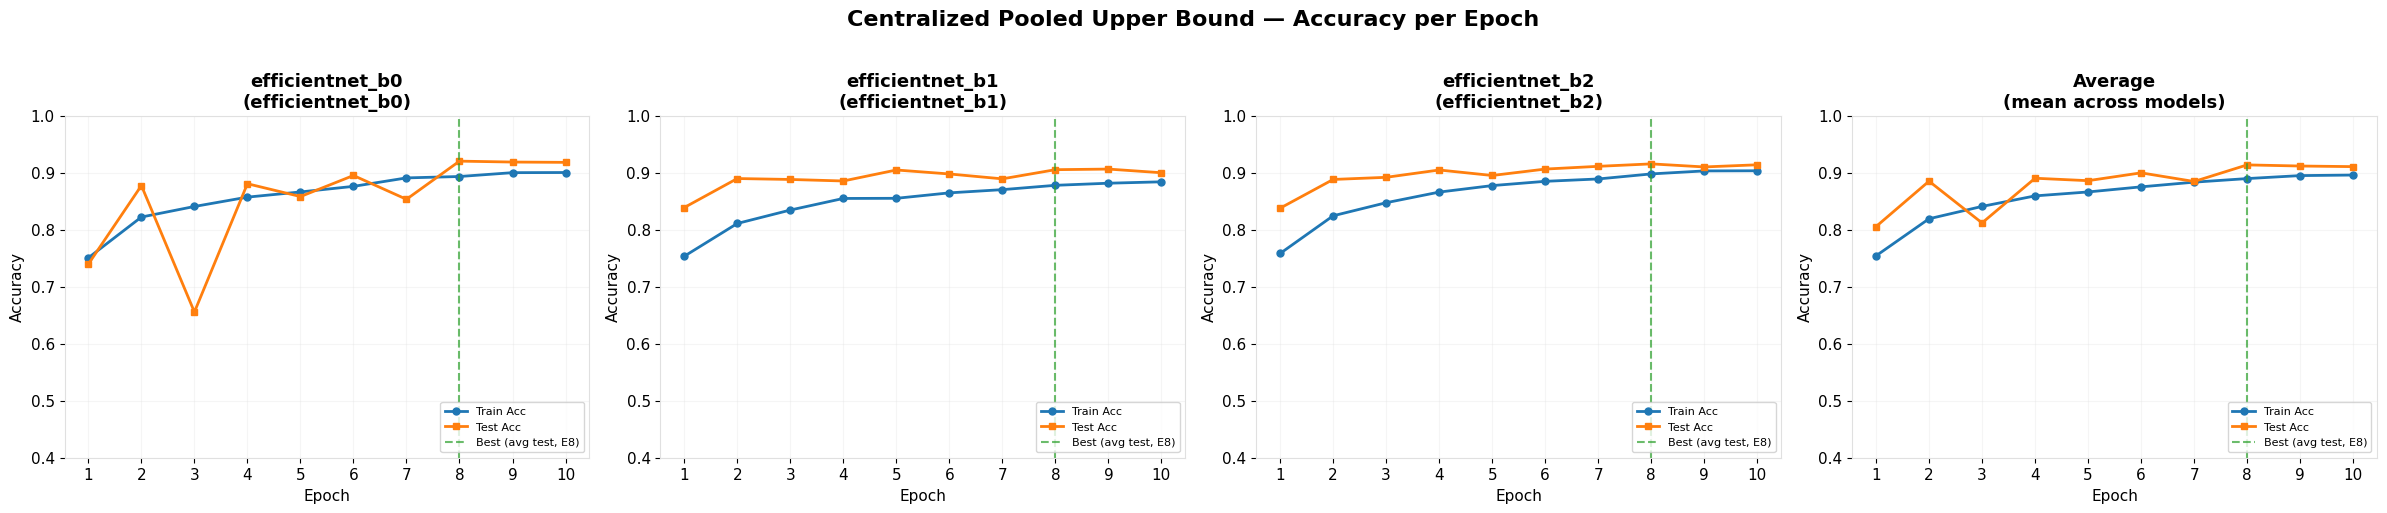

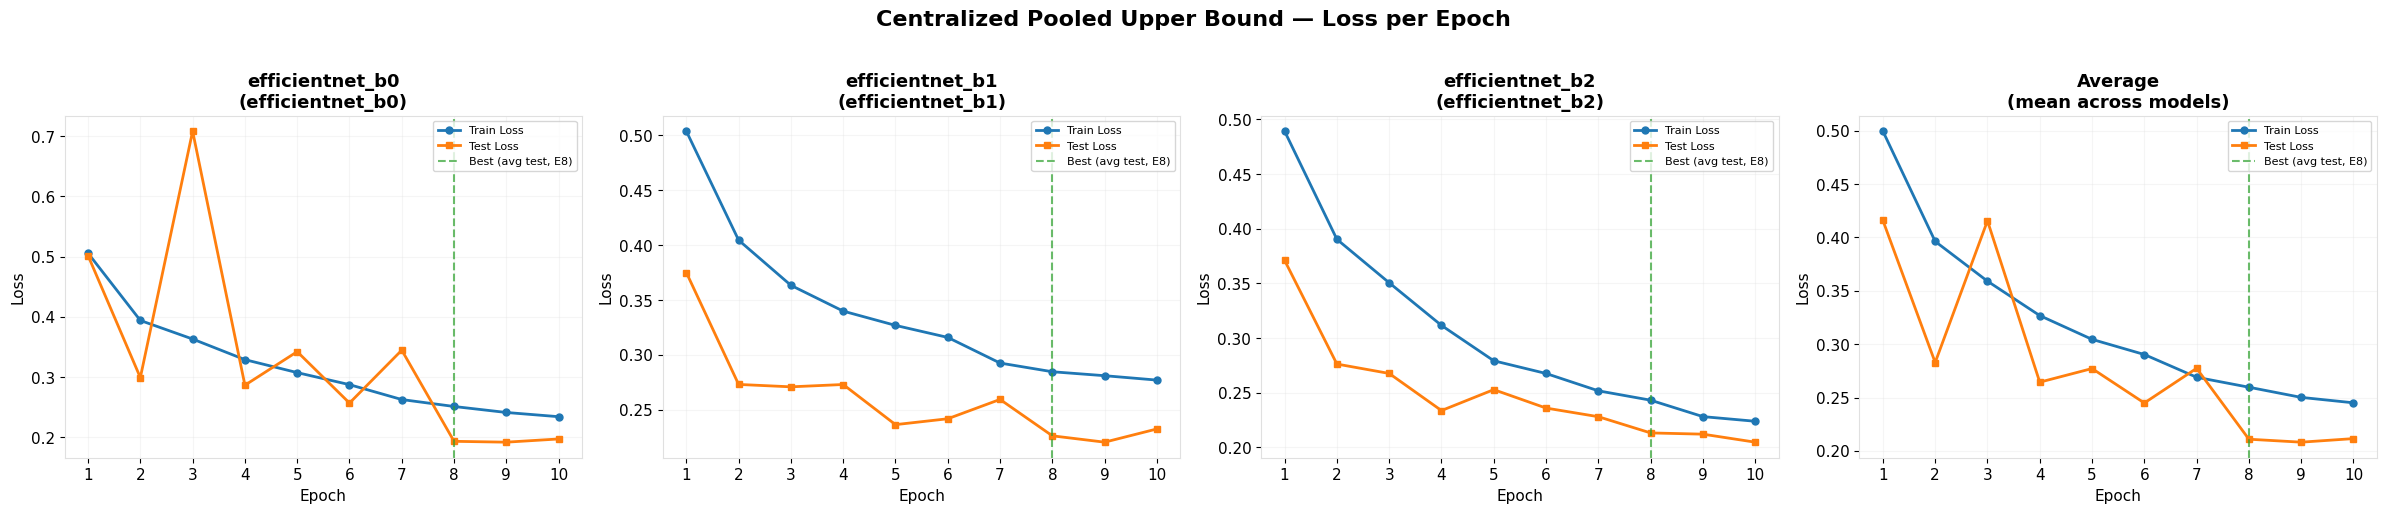

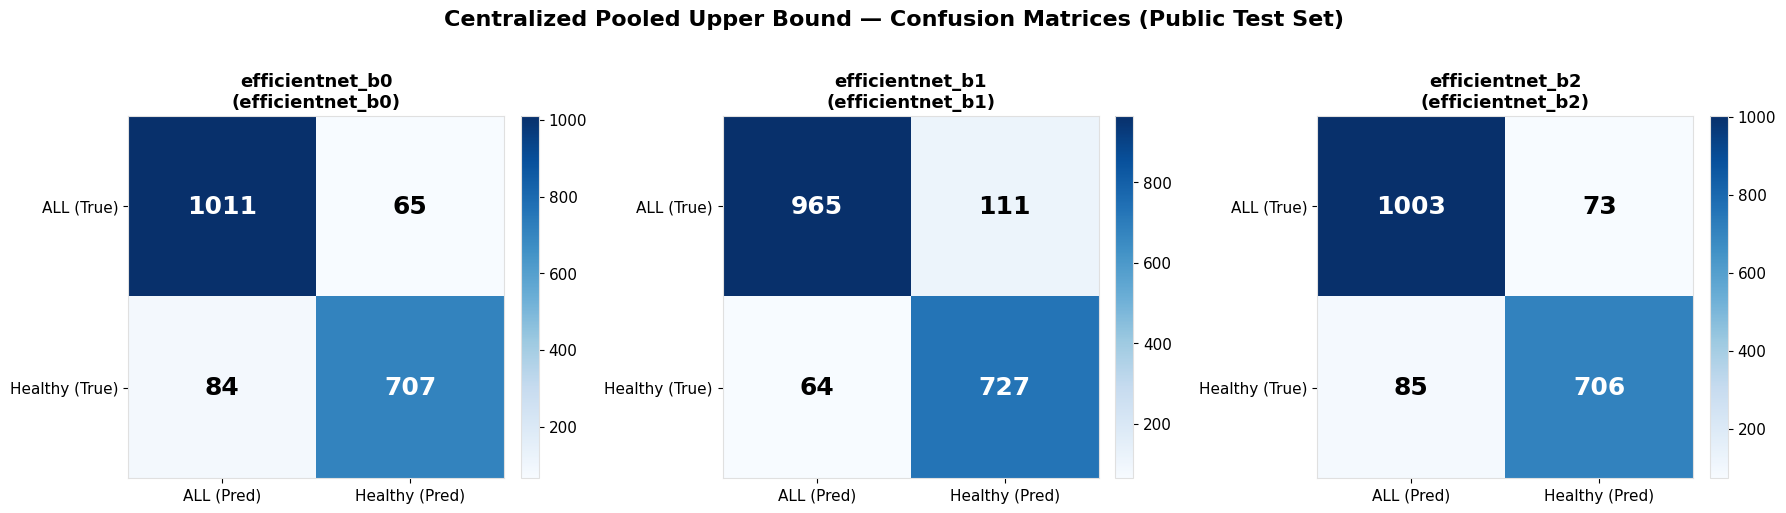


═══════════════════════════════════════════════════════════════════════════════════════════════
CENTRALIZED POOLED UPPER BOUND — TEST SET METRICS (Public Test Set)
═══════════════════════════════════════════════════════════════════════════════════════════════
Model                Accuracy         F1    Precision  Sensitivity  Specificity
───────────────────────────────────────────────────────────────────────────────────────────────
efficientnet_b0        92.0%     93.1%       92.3%       94.0%       89.4%
efficientnet_b1        90.6%     91.7%       93.8%       89.7%       91.9%
efficientnet_b2        91.5%     92.7%       92.2%       93.2%       89.3%
───────────────────────────────────────────────────────────────────────────────────────────────
AVERAGE                91.4%     92.5%       92.8%       92.3%       90.2%


In [7]:
# ─── Visualization (same style as other `federated_learning/ablations/` notebooks) ───
import matplotlib

if not CENTRALIZED_VIZ_DATA:
    print("Run the previous cell (`run_centralized_baseline`) first.")
else:
    plt.style.use('default')
    COLORS = {
        'train': '#1f77b4', 'val': '#ff7f0e', 'best': '#2ca02c',
        'accent': '#d62728', 'bg': '#ffffff', 'grid': '#e0e0e0', 'text': '#000000',
    }
    matplotlib.rcParams.update({
        'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg'],
        'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
        'text.color': COLORS['text'], 'xtick.color': COLORS['text'],
        'ytick.color': COLORS['text'], 'grid.color': COLORS['grid'], 'grid.alpha': 0.5,
        'font.size': 11, 'axes.titlesize': 13, 'figure.titlesize': 16,
    })

    viz = CENTRALIZED_VIZ_DATA
    client_names = [e['name'] for e in viz]
    n_clients = len(client_names)
    num_epochs = len(viz[0]['history']['train_acc'])
    epochs_x = list(range(1, num_epochs + 1))

    round_data = {}
    for entry in viz:
        name = entry['name']
        h = entry['history']
        round_data[name] = {
            'train_acc': h['train_acc'],
            'val_acc': h['test_acc'],
            'train_loss': h['train_loss'],
            'val_loss': h['test_loss'],
        }

    avg_data = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    for r_idx in range(num_epochs):
        for key in avg_data:
            vals = [
                round_data[n][key][r_idx] for n in client_names
                if r_idx < len(round_data[n][key]) and round_data[n][key][r_idx] is not None
            ]
            avg_data[key].append(sum(vals) / len(vals) if vals else None)

    best_epoch = None
    best_val_acc = -1.0
    for i, v in enumerate(avg_data['val_acc']):
        if v is not None and v > best_val_acc:
            best_val_acc = v
            best_epoch = i + 1

    all_plots = [(n, round_data[n]) for n in client_names] + [('Average', avg_data)]

    # Figure 1: Accuracy (train vs test — analogous to train vs val in FL)
    fig, axes = plt.subplots(1, n_clients + 1, figsize=(6 * (n_clients + 1), 5))
    fig.suptitle('Centralized Pooled Upper Bound — Accuracy per Epoch', fontsize=16, fontweight='bold', y=1.02)

    for idx, (name, rd) in enumerate(all_plots):
        ax = axes[idx]
        ax.plot(epochs_x, rd['train_acc'], color=COLORS['train'], marker='o', ms=5, lw=2, label='Train Acc')
        ax.plot(epochs_x, rd['val_acc'], color=COLORS['val'], marker='s', ms=5, lw=2, label='Test Acc')
        if best_epoch:
            ax.axvline(x=best_epoch, color=COLORS['best'], ls='--', alpha=0.7,
                       label=f'Best (avg test, E{best_epoch})')
        lbl = f"\n({name})" if name != 'Average' else '\n(mean across models)'
        ax.set_title(f'{name}{lbl}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(epochs_x)
        ax.set_ylim(0.4, 1.0)
    plt.tight_layout()
    plt.show()

    # Figure 2: Loss
    fig, axes = plt.subplots(1, n_clients + 1, figsize=(6 * (n_clients + 1), 5))
    fig.suptitle('Centralized Pooled Upper Bound — Loss per Epoch', fontsize=16, fontweight='bold', y=1.02)

    for idx, (name, rd) in enumerate(all_plots):
        ax = axes[idx]
        ax.plot(epochs_x, rd['train_loss'], color=COLORS['train'], marker='o', ms=5, lw=2, label='Train Loss')
        ax.plot(epochs_x, rd['val_loss'], color=COLORS['val'], marker='s', ms=5, lw=2, label='Test Loss')
        if best_epoch:
            ax.axvline(x=best_epoch, color=COLORS['best'], ls='--', alpha=0.7,
                       label=f'Best (avg test, E{best_epoch})')
        lbl = f"\n({name})" if name != 'Average' else '\n(mean across models)'
        ax.set_title(f'{name}{lbl}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(epochs_x)
    plt.tight_layout()
    plt.show()

    # Figure 3: Confusion matrices (public test set)
    fig, axes = plt.subplots(1, n_clients, figsize=(6 * n_clients, 5))
    if n_clients == 1:
        axes = [axes]
    fig.suptitle(
        'Centralized Pooled Upper Bound — Confusion Matrices (Public Test Set)',
        fontsize=16, fontweight='bold', y=1.02,
    )

    for idx, name in enumerate(client_names):
        cm_dict = viz[idx]['metrics']['confusion_matrix']
        TP = cm_dict.get('TP', 0)
        FP = cm_dict.get('FP', 0)
        FN = cm_dict.get('FN', 0)
        TN = cm_dict.get('TN', 0)
        matrix = np.array([[TP, FN], [FP, TN]])

        ax = axes[idx]
        im = ax.imshow(matrix, cmap='Blues', aspect='auto')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['ALL (Pred)', 'Healthy (Pred)'])
        ax.set_yticklabels(['ALL (True)', 'Healthy (True)'])
        ax.set_title(f'{name}\n({viz[idx]["metrics"]["Model"]})', fontweight='bold')

        for i in range(2):
            for j in range(2):
                ax.text(
                    j, i, str(matrix[i, j]), ha='center', va='center',
                    fontsize=18, fontweight='bold',
                    color='white' if matrix[i, j] > matrix.max() / 2 else 'black',
                )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # Metrics table (same layout as FL post-FL table)
    print(f"\n{'═' * 95}")
    print("CENTRALIZED POOLED UPPER BOUND — TEST SET METRICS (Public Test Set)")
    print(f"{'═' * 95}")
    header = (
        f"{'Model':<18} {'Accuracy':>10} {'F1':>10} {'Precision':>12} "
        f"{'Sensitivity':>12} {'Specificity':>12}"
    )
    print(header)
    print(f"{'─' * 95}")

    sums = {'accuracy': 0.0, 'f1_score': 0.0, 'precision': 0.0, 'recall': 0.0, 'specificity': 0.0}
    for entry in viz:
        m = entry['metrics']
        name = m['Model']
        print(
            f"{name:<18} {m.get('accuracy', 0):>9.1%} {m.get('f1_score', 0):>9.1%} "
            f"{m.get('precision', 0):>11.1%} {m.get('recall', 0):>11.1%} "
            f"{m.get('specificity', 0):>11.1%}"
        )
        for k in sums:
            sums[k] += float(m.get(k, 0) or 0)

    n = len(viz)
    print(f"{'─' * 95}")
    print(
        f"{'AVERAGE':<18} {sums['accuracy']/n:>9.1%} {sums['f1_score']/n:>9.1%} "
        f"{sums['precision']/n:>11.1%} {sums['recall']/n:>11.1%} {sums['specificity']/n:>11.1%}"
    )